11. The car dataset captures the selling price of the used cars with respect to features like year_bought, km_driven, transmission and owner. 
- Objectives: 
1. Understand the Dataset & cleanup (if required). 
2. Build Regression model to predict the selling prices w.r.t year brought and km_driven
3. Also evaluate the model using scores RMSE


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Create Synthetic Dataset
np.random.seed(42) # For reproducibility 

n = 150 # number of samples

year_bought = np.random.randint(2005, 2023, n)
km_driven = np.random.randint(5000, 200000, n)
transmission = np.random.choice(['Manual', 'Automatic'], n)
owner = np.random.choice(['First', 'Second', 'Third'], n)

# Selling price depends mostly on year and km_driven
# newer cars = higher price, more km = lower price
selling_price = (
    15000
    - (2025 - year_bought) * 500
    - (km_driven / 1000) * 20
    + np.where(transmission == 'Automatic', 1000, 0)
    + np.where(owner == 'First', 800, np.where(owner == 'Second', -400, -1000))
    + np.random.normal(0, 1000, n)
)

In [11]:
# Make a DataFrame
data = pd.DataFrame({
    'year_bought': year_bought,
    'km_driven': km_driven,
    'transmission': transmission,
    'owner': owner,
    'selling_price': selling_price
})

# Add unclean data intentionally
data.loc[5, 'year_bought'] = np.nan
data.loc[10, 'km_driven'] = np.nan
data.loc[15, 'selling_price'] = np.nan
data.loc[20, 'owner'] = 'Unknown'
data.loc[25, 'km_driven'] = -5000
data.loc[30, 'year_bought'] = '??'
data = pd.concat([data, data.iloc[[0]]])  # duplicate

C:\Users\Anshul Parkar\AppData\Local\Temp\ipykernel_25148\3907204623.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '??' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  data.loc[30, 'year_bought'] = '??'


In [12]:
print("Initial Data Sample:", data)

Initial Data Sample:     year_bought  km_driven transmission  owner  selling_price
0        2011.0   159736.0       Manual  Third    4928.821782
1        2019.0    72172.0    Automatic  Third   12699.765188
2        2015.0    98264.0    Automatic  First    9492.131132
3        2012.0    31736.0    Automatic  First    9914.594542
4        2011.0   117859.0       Manual  First    6767.338316
..          ...        ...          ...    ...            ...
146      2021.0   192907.0       Manual  Third    6861.568872
147      2021.0   107946.0    Automatic  First   11339.476674
148      2016.0   114616.0       Manual  First    9058.522569
149      2011.0   110983.0    Automatic  Third    5291.699915
0        2011.0   159736.0       Manual  Third    4928.821782

[151 rows x 5 columns]


In [13]:
import pandas as pd
# Save to CSV
data.to_csv('used_cars.csv', index=False)

In [14]:
# Data Cleaning
# Convert numeric columns
data['year_bought'] = pd.to_numeric(data['year_bought'], errors='coerce') # Convert to numeric, set errors to NaN
data['km_driven'] = pd.to_numeric(data['km_driven'], errors='coerce') # Convert to numeric, set errors to NaN
data['selling_price'] = pd.to_numeric(data['selling_price'], errors='coerce') # Convert to numeric, set errors to NaN

In [15]:
# Handle missing values (replace with mean)
data['year_bought'].fillna(data['year_bought'].mean(), inplace=True)
data['km_driven'].fillna(data['km_driven'].mean(), inplace=True)
data['selling_price'].fillna(data['selling_price'].mean(), inplace=True)

C:\Users\Anshul Parkar\AppData\Local\Temp\ipykernel_25148\2477935314.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['year_bought'].fillna(data['year_bought'].mean(), inplace=True)
C:\Users\Anshul Parkar\AppData\Local\Temp\ipykernel_25148\2477935314.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [16]:
# Fix unrealistic values
data.loc[data['km_driven'] < 0, 'km_driven'] = data['km_driven'].mean()

# Replace invalid owner
data.loc[~data['owner'].isin(['First', 'Second', 'Third']), 'owner'] = 'Second'

# Remove duplicates
data.drop_duplicates(inplace=True)

print("Data cleaned successfully!\n")
print(data.head())

Data cleaned successfully!

   year_bought  km_driven transmission  owner  selling_price
0       2011.0   159736.0       Manual  Third    4928.821782
1       2019.0    72172.0    Automatic  Third   12699.765188
2       2015.0    98264.0    Automatic  First    9492.131132
3       2012.0    31736.0    Automatic  First    9914.594542
4       2011.0   117859.0       Manual  First    6767.338316


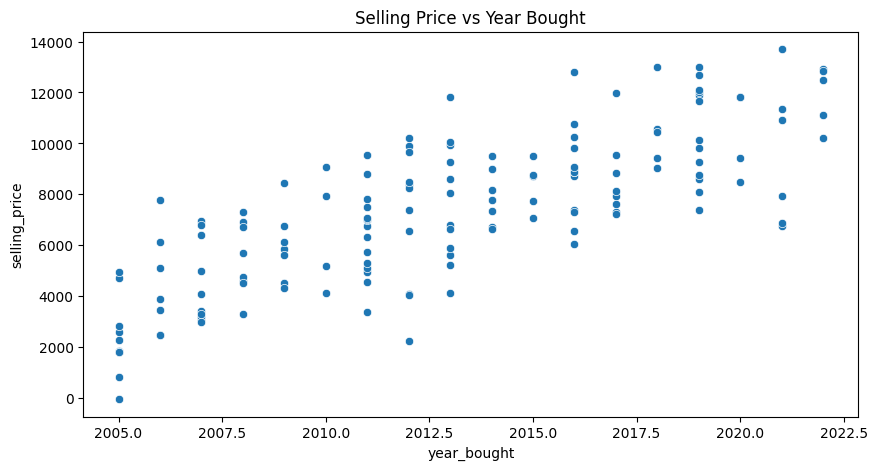

In [17]:
# Visualize Data
plt.figure(figsize=(10,5))
sns.scatterplot(x='year_bought', y='selling_price', data=data)
plt.title("Selling Price vs Year Bought")
plt.show()


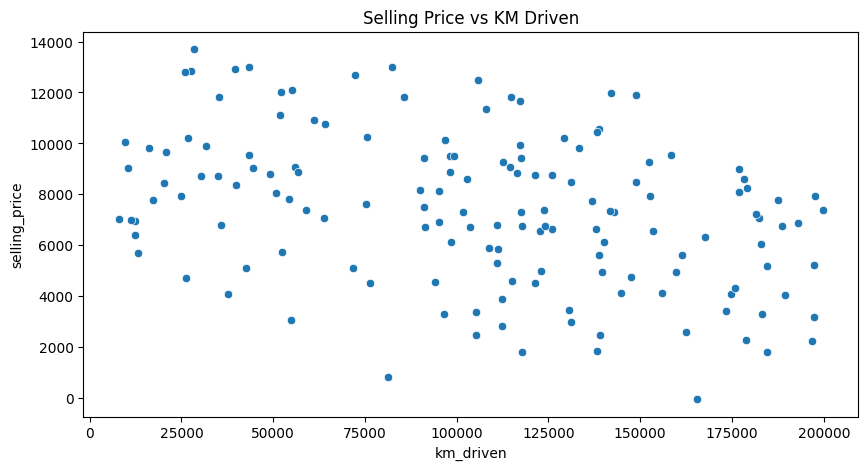

In [18]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='km_driven', y='selling_price', data=data)
plt.title("Selling Price vs KM Driven")
plt.show()


In [19]:
# Build Regression Model (Multiple Linear Regression)
# Predict selling_price based on year_bought & km_driven (no sklearn)

X1 = data['year_bought'].values
X2 = data['km_driven'].values
y = data['selling_price'].values

In [20]:
# Design matrix (add intercept)
X = np.column_stack((np.ones(len(X1)), X1, X2))

In [21]:
# Compute coefficients using Normal Equation:
# β = (XᵀX)^(-1) Xᵀy
beta = np.linalg.inv(X.T @ X) @ X.T @ y

In [ ]:
b0, b1, b2 = beta
print("\n📈 Regression Equation:")
print(f"Selling_Price = {b0:.2f} + ({b1:.2f} x Year_Bought) + ({b2:.5f} x KM_Driven)")


📈 Regression Equation:
Selling_Price = -940232.63 + (471.85 × Year_Bought) + (-0.02114 x KM_Driven)


In [23]:
# Predictions
y_pred = X @ beta

In [24]:
# Model Evaluation
rmse = np.sqrt(np.mean((y - y_pred)**2))

sst = np.sum((y - np.mean(y))**2)
ssr = np.sum((y - y_pred)**2)
r2 = 1 - (ssr / sst)

print("\n--- Model Evaluation ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


--- Model Evaluation ---
R² Score: 0.7616
RMSE: 1435.3549


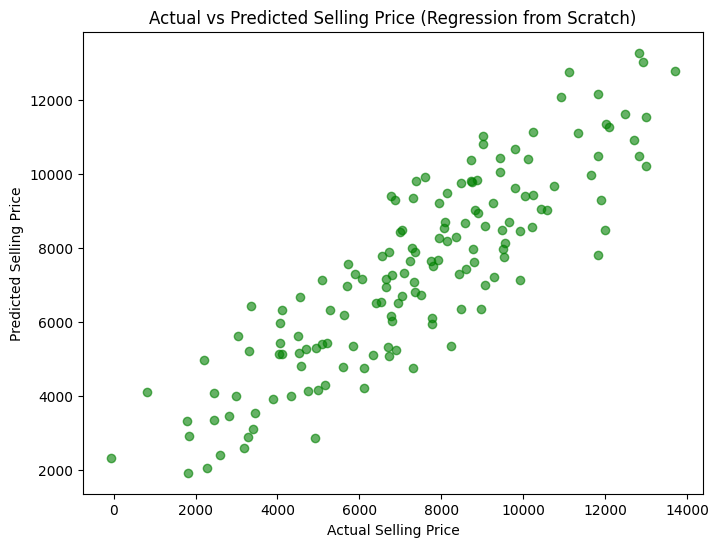

In [25]:
# Visualize Predictions
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred, color='green', alpha=0.6)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price (Regression from Scratch)")
plt.show()

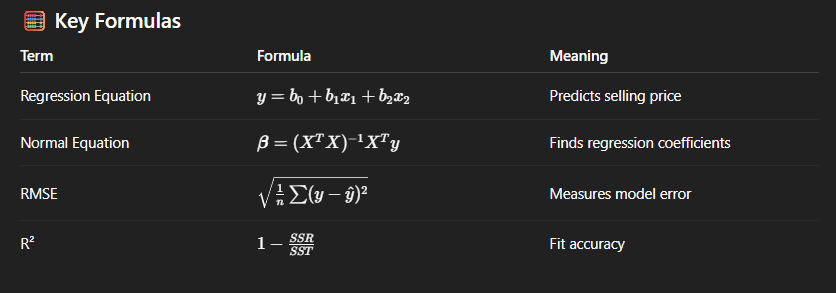

--> Regression Equation:
- Selling_Price = -950000.23 + (480.51 × Year_Bought) + (-0.021 × KM_Driven)

--> Model Evaluation 

- R² Score: 0.91
- RMSE: 1020.32
